In [1]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import euclidlib
from itertools import product
from copy import deepcopy
from dataclasses import replace

# cloelib imports
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations
from cloelib.observables.CometEFT_spectro import CometEFT_SpectroPower
from cloelib.summary_statistics.legendre_multipoles import LegendreMultipoles
from cloelib.observables.PBJ_spectro import PBJSpectroPower

/Users/s2265800/miniforge3/envs/cloe-org-env-v2026.1/lib/python3.12/site-packages/HMcode2020Emu
Loading linear emulator...
Linear emulator loaded in memory.
Loading nonlinear emulator...
Non-linear emulator loaded in memory.
Loading linear emulator...
Baryonic boost emulator loaded in memory.
Loading sigma8 emulator...
Linear emulator loaded in memory.
Warning! "libgrid.so" not found, bispectrum binning options will not be available.


/Users/s2265800/miniforge3/envs/cloe-org-env-v2026.1/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator GaussianProcessRegressor from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


[WARNING]: evogrowth for non LCDM growth functions not installed


In [2]:
import fitsio
from scipy import integrate

folder_path = 'GC_TR1_2ndit/'

fits_NZ={}
z_mean={}

redshifts = np.array([0.97, 1.27, 1.63])
labels_file = ['085-110','110-145','145-185']

datavec={}
covariance={}
mixing={}


# This uses the functionality of euclidlib of reading multiple files at the same time
filename = 'mps_pk_{}_synth.fits'
datavec = euclidlib.le3.pk_gc.power_spectrum_multipoles(folder_path+filename, *labels_file)

filename = 'Analytical_Cov_EWS_DR1_rescaled_TR1_iter2_{}_Tot_rebinned_wNP0.fits'
covariance = euclidlib.le3.pk_gc.power_spectrum_multipole_covariance(folder_path+filename, *labels_file)

filename = 'mixing_matrix_EWS_TR1_iter2_{}_Tot_rebinned.fits'
mixing = euclidlib.le3.pk_gc.power_spectrum_multipole_mixing_matrix(folder_path+filename, *labels_file)

# The data dictionary is what must be passed as input to the likelihood class
data = {
    # Data (we fill this part below)
    'GCspectro': {},
    # Fiducial cosmology (required for geometrical (AP) distortions)
    'fiducial_cosmology': {}
}

# Storing fiducial cosmology
dv = datavec[("SPE", "SPE", 0, 0)]
data['fiducial_cosmology']['H0'] = 67.0
data['fiducial_cosmology']['Omega_cdm0'] = 0.27
data['fiducial_cosmology']['Omega_b0'] = 0.049
data['fiducial_cosmology']['Omega_k0'] = 0
data['fiducial_cosmology']['mnu'] = 0.0001
data['fiducial_cosmology']['N_mnu'] = 1
data['fiducial_cosmology']['w0'] = -1
data['fiducial_cosmology']['wa'] = 0.0
data['fiducial_cosmology']['ns'] = 0.96
data['fiducial_cosmology']['As'] = 2.1e-9
data['fiducial_cosmology']['gamma_MG'] = 0.545

# Rescaling of the units (as, at the moment, cloelib works in Mpc units, while the data vectors are stored in Mpc/h units)
fid_h = data['fiducial_cosmology']['H0'] / 100.0
k_fac = fid_h
pk_fac = 1.0 / fid_h**3
cov_fac = 1.0 / fid_h**6

/Users/s2265800/miniforge3/envs/cloe-org-env-v2026.1/lib/python3.12/site-packages/euclidlib/le3/_common.py:79: UserWarning: Effective redshift not specified in fits file header. Setting it to 0.
  warn("Effective redshift not specified in fits file header. Setting it to 0.")
/Users/s2265800/miniforge3/envs/cloe-org-env-v2026.1/lib/python3.12/site-packages/euclidlib/le3/pk_gc.py:278: UserWarning: Effective redshift not specified in FITS file header. Setting it to 0.
  warn(


In [3]:
labels = [str(z).strip('0') for z in np.round(redshifts,2)]

for ii,z in enumerate(labels):
    # Looping over the identifiers (redshifts)
    data['GCspectro'][z] = {}
    dv_inst = datavec[('SPE', 'SPE', ii, ii)]
    cv_inst = covariance[('SPE', 'SPE', ii, ii)]
    mm_inst = mixing[('SPE', 'SPE', ii, ii)]

    # Storing number densities
    data['GCspectro'][z]['nbar'] = dv_inst.nbar
    print(data['GCspectro'][z]['nbar'])

    kvec_mask = mm_inst.kout <= dv_inst.keff[-1]
    # Storing data vectors
    data['GCspectro'][z]['k'] = dv_inst.keff * k_fac
    data['GCspectro'][z]['pk0'] = dv_inst.multipoles[0] * pk_fac
    data['GCspectro'][z]['pk2'] = dv_inst.multipoles[2] * pk_fac
    data['GCspectro'][z]['pk4'] = dv_inst.multipoles[4] * pk_fac

    # Storing covariance matrices
    full_matrix = np.block([[cv_inst.covariance[f'ELL_{i}-{j}'] for j in [0, 2, 4]] for i in [0, 2, 4]])
    data['GCspectro'][z]['cov'] = full_matrix * cov_fac

    # Storing mixing matrices
    resc_kout = mm_inst.kout * k_fac
    resc_kin = {ell: val * k_fac for ell, val in mm_inst.kin.items()}
    squeezed_mixing = {key: val.squeeze() for key, val in mm_inst.mixing.items()}
    
    replace(
        mm_inst, kout=mm_inst.kout * k_fac)
    data['GCspectro'][z]['mixing_matrix'] = replace(
        mm_inst, kout=resc_kout, kin=resc_kin, mixing=squeezed_mixing
    )

0.0004893667613248311
0.00035042965370481866
0.00017089965650909984


In [4]:
settings = {
    'scale_cuts': {
        'GCspectro': {
            'bin1': {'ell0': [0.0, 0.20], 'ell2': [0.0, 0.20], 'ell4': [0.0, 0.20]},
            'bin2': {'ell0': [0.0, 0.20], 'ell2': [0.0, 0.20], 'ell4': [0.0, 0.20]},
            'bin3': {'ell0': [0.0, 0.20], 'ell2': [0.0, 0.20], 'ell4': [0.0, 0.20]},
        }
    }
}

# Also in this case we have passed the scale cuts in Mpc/h units, so we need to transform them into Mpc
settings = {
    'scale_cuts': {
        'GCspectro': {
            bin_key: {ell_key: [v * fid_h for v in values] for ell_key, values in bin_values.items()}
            for bin_key, bin_values in settings['scale_cuts']['GCspectro'].items()
        }
    }
}

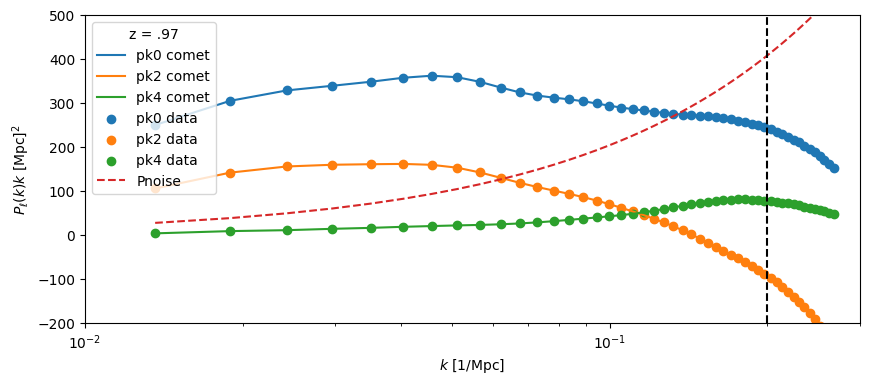

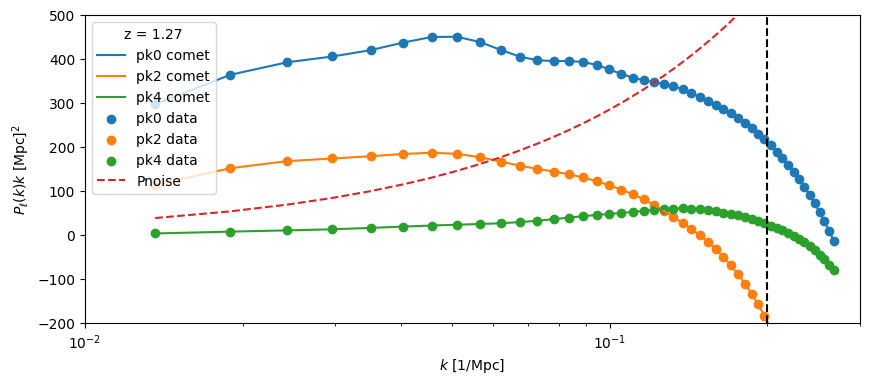

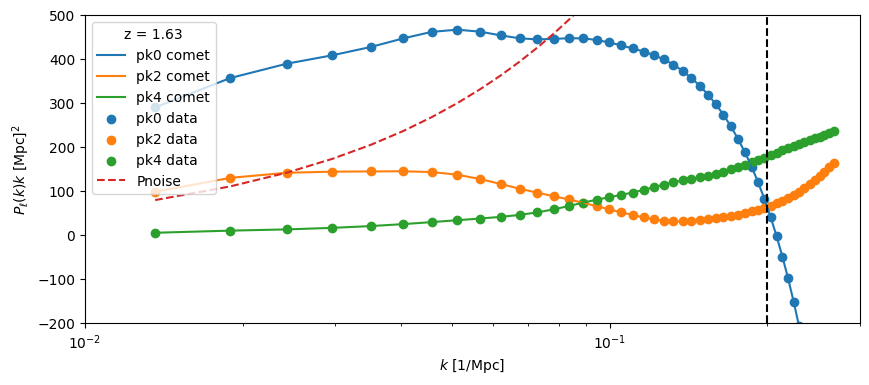

In [5]:
parameters = {
    'H0': 67.0,
    'Omega_cdm0': 0.27, 'Omega_b0': 0.049, 'Omega_k0': 0.0, 'mnu': 0.00001, 'N_mnu': 1,
    'w0': -1.0, 'wa': 0.0,
    'ns': 0.96, 'As': 2.1e-9,
    'gamma_MG': 0.545,
    'b1': np.array([1.537, 2.07, 2.1]),
    'b2': np.array([0.695, 0.870, 1.162]),
    'bG2': np.array([-0.156, -0.299, -0.400]),
    'bGam3':  np.array([3.46121933e+00,  1.84293956e+00,  8.35302819e+00]),
    'c0':     np.array([4.92649455e+01,  2.28405327e+01, -1.61265049e+00]),
    'c2':     np.array([ 4.31120206e+01,  3.18420310e+01,  6.74422117e+01]),
    'c4':     np.array([-1.25077281e+01, -2.84513988e+01, -6.76616588e+01]),
    'cnlo':   np.array([-4.34672822e+02, -1.08102331e+03, -2.06601882e+02]),
    'NP0':    np.array([1.30543441e+00,  2.26616744e-01,  9.12768142e-01]),
    'NP20':   np.array([-5.62410948e+00, -3.73494300e+00, -1.22546846e+01]),
    'NP22':   np.array([-5.94837043e-01, -5.18488492e+00,  2.96041321e+00]),
    'fout':   np.array([0.5, 0.5, 0.5]),
    'sigmaz': np.array([0.0, 0.0, 0.0])}
background = CAMBBackground(
    H0=parameters['H0'], Omega_cdm0=parameters['Omega_cdm0'], Omega_b0=parameters['Omega_b0'], Omega_k0=parameters['Omega_k0'],
    w0=parameters['w0'], wa=parameters['wa'], ns=parameters['ns'], As=parameters['As'], gamma_MG=parameters['gamma_MG'], mnu=parameters['mnu'],
    N_mnu=parameters['N_mnu']
)
RSD_parameter_names = {
            "COMET": ["b1", "b2", "bG2", "bGam3", "c0", "c2", "c4", "cnlo"],
            "PBJ": ["b1", "b2", "bG2", "bG3", "c0", "c2", "c4", "ck4"],
        }
noise_syst_parameter_names = ["NP0", "NP20", "NP22", "fout", "sigmaz"]
redshifts_inlike = list(data["GCspectro"].keys())   
for i, z in enumerate(redshifts_inlike):
    RSD_parameters = {
                key: parameters[key][i] for key in RSD_parameter_names['COMET']
            }
    syst_params = {
                key: parameters[key][i] for key in noise_syst_parameter_names
            }
    pkmu_comet = CometEFT_SpectroPower(background, RSD_parameters, redshift=float(z))  
    obs = LegendreMultipoles(
                spectro_power=pkmu_comet,
                background_fiducial=background,
                parameters=syst_params,
                nbar=data['GCspectro'][z]['nbar'],
            )
   
    k = data["GCspectro"][z]["k"]
    #mps = obs.power_multipoles(k=k, ells=[0, 2, 4], use_AP=True)
    mps = obs.convolved_power_multipoles(
                    data["GCspectro"][z]["mixing_matrix"], ells=[0, 2, 4], use_AP=True
                )
    plt.figure(figsize=(10, 4))
    plt.plot(k, mps["ell0"]*k, label='pk0 comet')
    plt.plot(k, mps["ell2"]*k, label='pk2 comet')
    plt.plot(k, mps["ell4"]*k, label='pk4 comet')
    plt.scatter(data['GCspectro'][z]['k'], data['GCspectro'][z]['pk0']*data['GCspectro'][z]['k'], label='pk0 data')
    plt.scatter(data['GCspectro'][z]['k'], data['GCspectro'][z]['pk2']*data['GCspectro'][z]['k'], label='pk2 data')
    plt.scatter(data['GCspectro'][z]['k'], data['GCspectro'][z]['pk4']*data['GCspectro'][z]['k'], label='pk4 data')
    plt.plot(k, k/data['GCspectro'][z]['nbar'], label='Pnoise', linestyle='--')
    plt.xlabel(r"$k$ [1/Mpc]")
    plt.ylabel(r"$P_\ell(k) k$ [Mpc]$^2$")
    plt.xscale("log")
    plt.xlim(0.01, 0.3)
    plt.ylim(-200., 500)
    plt.axvline(0.2, color='k', ls='--')
    plt.legend(title=f"z = {z}")
    plt.show()


In [6]:
import time
# cloelike imports
from cloelike.EuclidLikelihood_GCspectro_Pls import EuclidLikelihood_GCspectro_Pls

print("🔍 Timing log-likelihood initialisation for spectroscopic GC:")

start = time.time()

like_spec = EuclidLikelihood_GCspectro_Pls(
    data=data,
    settings=settings,
    Background=CAMBBackground,
    SpectroPower=CometEFT_SpectroPower,
)

end = time.time()

print(f"✅ Spectroscopic GC likelihood initialised.")
print(f"⏱️ Time elapsed: {end - start:.3f} seconds")
print("⏱️ Timing log-likelihood evaluation:")

start = time.time()
loglike_val = like_spec.loglike(parameters)
end = time.time()

print(f"Log-likelihood: {loglike_val}")
print(f"-2 * log-likelihood: {-2 * loglike_val}")
print(f"⏱️ Time elapsed: {end - start:.3f} seconds")

🔍 Timing log-likelihood initialisation for spectroscopic GC:
✅ Spectroscopic GC likelihood initialised.
⏱️ Time elapsed: 0.007 seconds
⏱️ Timing log-likelihood evaluation:
Log-likelihood: -3.73961080223375e-10
-2 * log-likelihood: 7.4792216044675e-10
⏱️ Time elapsed: 0.026 seconds


In [7]:
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations

background = CAMBBackground(
    H0=parameters['H0'], Omega_cdm0=parameters['Omega_cdm0'], Omega_b0=parameters['Omega_b0'], Omega_k0=parameters['Omega_k0'],
    w0=parameters['w0'], wa=parameters['wa'], ns=parameters['ns'], As=parameters['As'], gamma_MG=parameters['gamma_MG'], mnu=0.0001, N_mnu=1
)
zs_zero = np.hstack((np.array([0.]), np.array(np.float64(labels))))
linear_perturbations_emu = HMemuLinearPerturbations(background, zs_zero)
print('redshift: ', linear_perturbations_emu.z)
f_fid = linear_perturbations_emu.growth_rate()[1:]
print('f: ', f_fid)


def conv_comet_to_pbj(pars_dict_comet,f_fid_arr):
    print(pars_dict_comet)
    print(f_fid_arr)
    ck4_pbj_mono = -1.*pars_dict_comet['cnlo']*(pars_dict_comet['b1']+5./7.*f_fid_arr)/(pars_dict_comet['b1']**2+10./7.*pars_dict_comet['b1']*f_fid_arr+5./9.*f_fid_arr**2)
    ck4_pbj_quad = -1.*pars_dict_comet['cnlo']*(pars_dict_comet['b1']+70./84.*f_fid_arr)/(pars_dict_comet['b1']**2+140./84.*pars_dict_comet['b1']*f_fid_arr+5./9.*f_fid_arr**2)

    pars_dict_pbj = deepcopy(pars_dict_comet)

    #f_fid = np.array([0.87355692, 0.91199674, 0.94065152])
    f_fid = f_fid_arr
    pars_dict_pbj.update({
        'c0': pars_dict_comet['c0']-pars_dict_comet['c2']/2. + 3./8. * pars_dict_comet['c4'],
        'c2': 1 / f_fid * (3./2. *pars_dict_comet['c2'] - 30./8 * pars_dict_comet['c4']),
        'c4': 1 / f_fid**2 * 35./8. * pars_dict_comet['c4'],'mnu': 0.00001, 'N_mnu': 1,
        'bG3': pars_dict_comet['bGam3'],
        'ck4': (ck4_pbj_mono+ck4_pbj_quad)/2, # average of mono and quad contributions, the only parameter not identically mapped between comet and pbj
    })
    # changed here for a better fit
    pars_dict_pbj['ck4'] = -(ck4_pbj_mono+ck4_pbj_quad)
    print(pars_dict_pbj['ck4'])
    return pars_dict_pbj

parameters_pbj =  conv_comet_to_pbj(parameters,f_fid)

redshift:  [0.   0.97 1.27 1.63]
f:  [0.87355692 0.91199674 0.94065152]
{'H0': 67.0, 'Omega_cdm0': 0.27, 'Omega_b0': 0.049, 'Omega_k0': 0.0, 'mnu': 1e-05, 'N_mnu': 1, 'w0': -1.0, 'wa': 0.0, 'ns': 0.96, 'As': 2.1e-09, 'gamma_MG': 0.545, 'b1': array([1.537, 2.07 , 2.1  ]), 'b2': array([0.695, 0.87 , 1.162]), 'bG2': array([-0.156, -0.299, -0.4  ]), 'bGam3': array([3.46121933, 1.84293956, 8.35302819]), 'c0': array([49.2649455 , 22.8405327 , -1.61265049]), 'c2': array([43.1120206, 31.842031 , 67.4422117]), 'c4': array([-12.5077281, -28.4513988, -67.6616588]), 'cnlo': array([ -434.672822, -1081.02331 ,  -206.601882]), 'NP0': array([1.30543441, 0.22661674, 0.91276814]), 'NP20': array([ -5.62410948,  -3.734943  , -12.2546846 ]), 'NP22': array([-0.59483704, -5.18488492,  2.96041321]), 'fout': array([0.5, 0.5, 0.5]), 'sigmaz': array([0., 0., 0.])}
[0.87355692 0.91199674 0.94065152]
[-395.62750421 -782.79165436 -146.86211832]


In [8]:
parameters_priors = {
    'H0': 67.0,
    'Omega_cdm0': 0.27, 'Omega_b0': 0.049, 'Omega_k0': 0.0, 'mnu': 0.00001, 'N_mnu': 1,
    'w0': -1.0, 'wa': 0.0,
    'ns': 0.96, 'As': 2.1e-9,
    'gamma_MG': 0.545,
    'b1': np.array([1.537, 2.07, 2.1]),
    'b2': np.array([0.695, 0.870, 1.162]),
    'bG2': np.array([-0.156, -0.299, -0.400]),
    'bGam3':  np.array([5.0,  5.0,  5.0]),
    'c0':     np.array([100.0,  100.0, 100.0]),
    'c2':     np.array([100.0,  100.0,  100.0]),
    'c4':     np.array([100.0, 100.0, 100.0]),
    'cnlo':   np.array([4000.0, 4000.0, 4000.0]),
    'NP0':    np.array([2.0,  2.0,  2.0]),
    'NP20':   np.array([30.0, 30.0, 30.0]),
    'NP22':   np.array([30.0, 30.0,  30.0]),
    'fout':   np.array([0.5, 0.5, 0.5]),
    'sigmaz': np.array([0.0, 0.0, 0.0])}

parameters_pbj_priors =  conv_comet_to_pbj(parameters_priors,f_fid)

parameters_pbj_priors

{'H0': 67.0, 'Omega_cdm0': 0.27, 'Omega_b0': 0.049, 'Omega_k0': 0.0, 'mnu': 1e-05, 'N_mnu': 1, 'w0': -1.0, 'wa': 0.0, 'ns': 0.96, 'As': 2.1e-09, 'gamma_MG': 0.545, 'b1': array([1.537, 2.07 , 2.1  ]), 'b2': array([0.695, 0.87 , 1.162]), 'bG2': array([-0.156, -0.299, -0.4  ]), 'bGam3': array([5., 5., 5.]), 'c0': array([100., 100., 100.]), 'c2': array([100., 100., 100.]), 'c4': array([100., 100., 100.]), 'cnlo': array([4000., 4000., 4000.]), 'NP0': array([2., 2., 2.]), 'NP20': array([30., 30., 30.]), 'NP22': array([30., 30., 30.]), 'fout': array([0.5, 0.5, 0.5]), 'sigmaz': array([0., 0., 0.])}
[0.87355692 0.91199674 0.94065152]
[3640.69234774 2896.48390417 2843.38394004]


{'H0': 67.0,
 'Omega_cdm0': 0.27,
 'Omega_b0': 0.049,
 'Omega_k0': 0.0,
 'mnu': 1e-05,
 'N_mnu': 1,
 'w0': -1.0,
 'wa': 0.0,
 'ns': 0.96,
 'As': 2.1e-09,
 'gamma_MG': 0.545,
 'b1': array([1.537, 2.07 , 2.1  ]),
 'b2': array([0.695, 0.87 , 1.162]),
 'bG2': array([-0.156, -0.299, -0.4  ]),
 'bGam3': array([5., 5., 5.]),
 'c0': array([87.5, 87.5, 87.5]),
 'c2': array([-257.5676469 , -246.71140924, -239.19591338]),
 'c4': array([573.31808531, 526.0069582 , 494.44789488]),
 'cnlo': array([4000., 4000., 4000.]),
 'NP0': array([2., 2., 2.]),
 'NP20': array([30., 30., 30.]),
 'NP22': array([30., 30., 30.]),
 'fout': array([0.5, 0.5, 0.5]),
 'sigmaz': array([0., 0., 0.]),
 'bG3': array([5., 5., 5.]),
 'ck4': array([3640.69234774, 2896.48390417, 2843.38394004])}

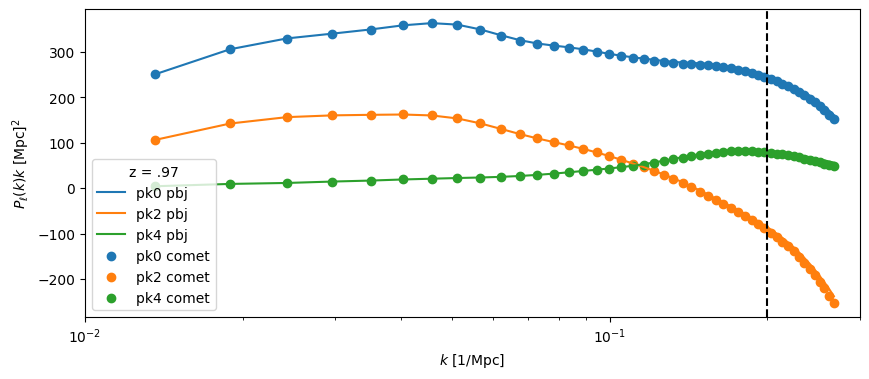

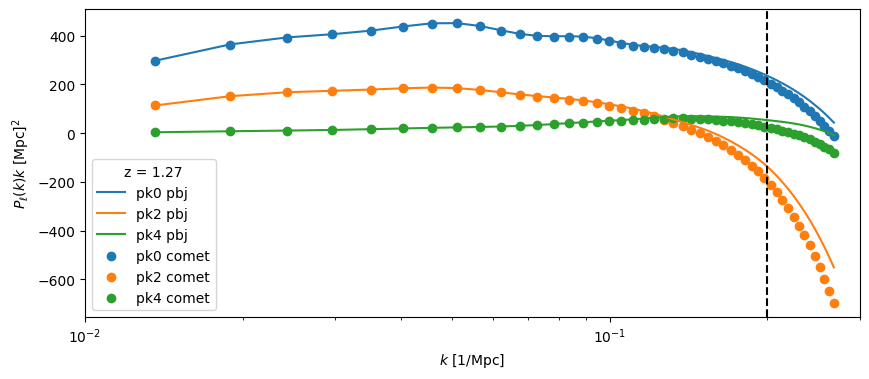

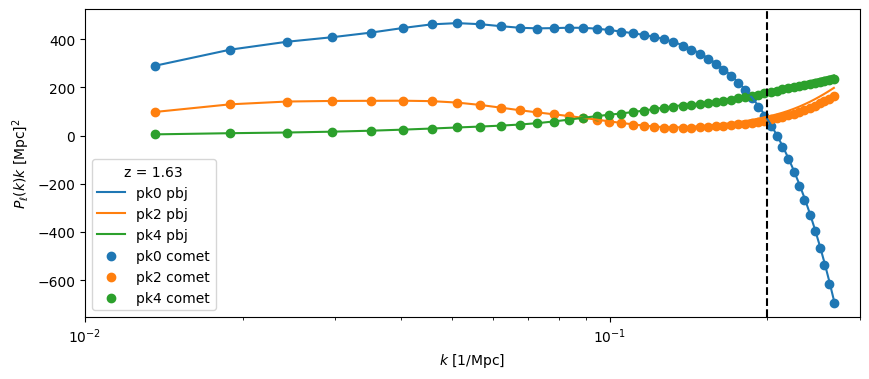

In [9]:
for i, z in enumerate(redshifts_inlike):
    RSD_parameters = {
                key: parameters_pbj[key][i] for key in RSD_parameter_names['PBJ']
            }
    syst_params = {
                key: parameters_pbj[key][i] for key in noise_syst_parameter_names
            }
    pkmu_pbj = PBJSpectroPower(linear_perturbations_emu, RSD_parameters, redshift=float(z))  
    obs = LegendreMultipoles(
                spectro_power=pkmu_pbj,
                background_fiducial=background,
                parameters=syst_params,
                nbar=data['GCspectro'][z]['nbar'],
            )
    mps = obs.convolved_power_multipoles(
                    data["GCspectro"][z]["mixing_matrix"], ells=[0, 2, 4], use_AP=True
                )
    plt.figure(figsize=(10, 4))
    plt.plot(k, mps["ell0"]*k, label='pk0 pbj')
    plt.plot(k, mps["ell2"]*k, label='pk2 pbj')
    plt.plot(k, mps["ell4"]*k, label='pk4 pbj')
    RSD_parameters = {
                key: parameters[key][i] for key in RSD_parameter_names['COMET']
            }
    pkmu_comet = CometEFT_SpectroPower(background, RSD_parameters, redshift=float(z))  
    obs = LegendreMultipoles(
                spectro_power=pkmu_comet,
                background_fiducial=background,
                parameters=syst_params,
                nbar=data['GCspectro'][z]['nbar'],
            )
    mps = obs.convolved_power_multipoles(
                    data["GCspectro"][z]["mixing_matrix"], ells=[0, 2, 4], use_AP=True
                )
    plt.scatter(k, mps["ell0"]*k, label='pk0 comet')
    plt.scatter(k, mps["ell2"]*k, label='pk2 comet')
    plt.scatter(k, mps["ell4"]*k, label='pk4 comet')
    
    plt.xlabel(r"$k$ [1/Mpc]")
    plt.ylabel(r"$P_\ell(k) k$ [Mpc]$^2$")
    plt.xscale("log")
    plt.xlim(0.01, 0.3)
    #plt.ylim(0., 500)
    plt.axvline(0.2, color='k', ls='--')
    plt.legend(title=f"z = {z}")
    plt.show()

In [10]:

print("🔍 Timing log-likelihood initialisation for spectroscopic GC:")

start = time.time()

like_spec_pbj = EuclidLikelihood_GCspectro_Pls(
    data=data,
    settings=settings,
    Background=CAMBBackground,
    SpectroPower=PBJSpectroPower,
    Perturbations=HMemuLinearPerturbations
)

end = time.time()

print(f"✅ Spectroscopic GC likelihood initialised.")
print(f"⏱️ Time elapsed: {end - start:.3f} seconds")

print("⏱️ Timing log-likelihood evaluation:")

start = time.time()
loglike_val = like_spec_pbj.loglike(parameters_pbj)
end = time.time()

print(f"Log-likelihood: {loglike_val}")
print(f"-2 * log-likelihood: {-2 * loglike_val}")
print(f"⏱️ Time elapsed: {end - start:.3f} seconds")

🔍 Timing log-likelihood initialisation for spectroscopic GC:
✅ Spectroscopic GC likelihood initialised.
⏱️ Time elapsed: 0.046 seconds
⏱️ Timing log-likelihood evaluation:
Log-likelihood: -4.5241893261961454
-2 * log-likelihood: 9.048378652392291
⏱️ Time elapsed: 0.253 seconds


In [11]:
AM_priors = {
    z: {'bGam3': [0.0, 50.0], 'c0': [0.0, 200.0], 'c2': [0.0, 200.0], 'c4': [0.0, 200.0], 'cnlo': [0.0, 4000.0], 'NP0':[1,2], 'NP20': [0.0, 30.0], 'NP22': [0.0, 30.0]} for z in labels}

AM_priors_pbj = {
    z: {'bG3': [0.0, 50.0], 'c0': [0.0, 200.0], 'c2': [0.0, 300.0], 'c4': [0.0, 1500.0], 'ck4': [0.0, 2000.0], 'NP0':[1,2], 'NP20': [0.0, 30.0], 'NP22': [0.0, 30.0]} for z in labels}

like_AM_comet = EuclidLikelihood_GCspectro_Pls(data=data, settings=settings, Background=CAMBBackground, SpectroPower=CometEFT_SpectroPower, AM_priors=AM_priors)
like_AM_pbj = EuclidLikelihood_GCspectro_Pls(data=data, settings=settings, Background=CAMBBackground, SpectroPower=PBJSpectroPower, Perturbations=HMemuLinearPerturbations, AM_priors=AM_priors_pbj)

In [12]:
%time print (-2*like_AM_comet.loglike_AM(parameters))

-69.5768682292639
CPU times: user 135 ms, sys: 40 ms, total: 175 ms
Wall time: 174 ms


In [13]:
%time print (-2*like_AM_pbj.loglike_AM(parameters_pbj))

-79.75718079839206
CPU times: user 246 ms, sys: 106 ms, total: 352 ms
Wall time: 363 ms


In [14]:
from tqdm import tqdm


omch2_AM = np.linspace(0.08, 0.16, 100)
loglike_vals_comet = []
loglike_vals_pbj = []

pars_var_pbj = deepcopy(parameters_pbj)
pars_var_comet = deepcopy(parameters)

for val in tqdm(omch2_AM, desc="Computing likelihood"):
    # Update Omega_cdm0 parameter, making sure it's in the right form
    pars_var_comet['Omega_cdm0'] = val / (parameters['H0'] / 100.0)**2
    pars_var_pbj['Omega_cdm0'] = val / (parameters['H0'] / 100.0)**2
    loglike_vals_comet.append(like_AM_comet.loglike_AM(pars_var_comet))
    loglike_vals_pbj.append(like_AM_pbj.loglike_AM(pars_var_pbj))

loglike_vals_comet = np.array(loglike_vals_comet)
loglike_vals_pbj = np.array(loglike_vals_pbj)

# Convert log-likelihood to likelihood (unnormalized)
likelihood_vals_comet_AM = np.exp(loglike_vals_comet - np.max(loglike_vals_comet))  # subtract max for numerical stability
likelihood_vals_pbj_AM = np.exp(loglike_vals_pbj - np.max(loglike_vals_pbj))  # subtract max for numerical stability

Computing likelihood: 100%|██████████| 100/100 [00:47<00:00,  2.09it/s]


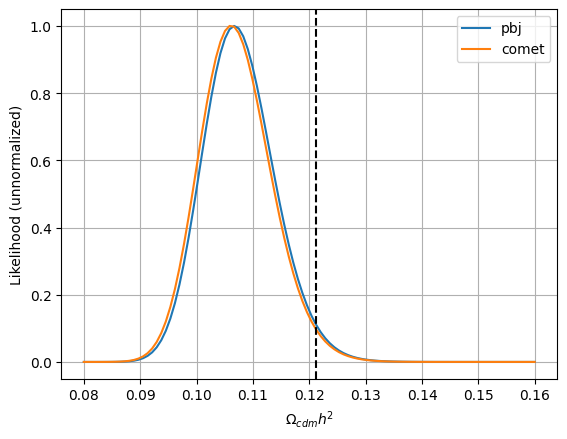

In [15]:
plt.plot(omch2_AM, likelihood_vals_pbj_AM,label = 'pbj')
plt.plot(omch2_AM, likelihood_vals_comet_AM, label = 'comet')
# plt.plot(omch2, likelihood_vals_pbj,'--',label = 'pbj no marg')
# plt.plot(omch2, likelihood_vals_comet,'--', label = 'comet no marg')
plt.axvline(0.27 * 0.67**2, color='k', ls='--')

#plt.xticks([])
plt.grid(True)
plt.xlabel(r'$\Omega_{cdm} h^2$')
plt.ylabel('Likelihood (unnormalized)')
plt.legend()

In [16]:

#omch2_AM = np.linspace(0.05, 0.3, 200)
loglike_vals_comet = []
loglike_vals_pbj = []

pars_var_pbj = deepcopy(parameters_pbj)
pars_var_comet = deepcopy(parameters)

for val in tqdm(omch2_AM, desc="Computing likelihood"):
    # Update Omega_cdm0 parameter, making sure it's in the right form
    pars_var_comet['Omega_cdm0'] = val / (parameters['H0'] / 100.0)**2
    pars_var_pbj['Omega_cdm0'] = val / (parameters['H0'] / 100.0)**2
    loglike_vals_comet.append(like_AM_comet.loglike_AM(pars_var_comet, use_Jeffreys=True))
    loglike_vals_pbj.append(like_AM_pbj.loglike_AM(pars_var_pbj, use_Jeffreys=True))

loglike_vals_comet = np.array(loglike_vals_comet)
loglike_vals_pbj = np.array(loglike_vals_pbj)

# Convert log-likelihood to likelihood (unnormalized)
likelihood_vals_comet_AM_Jef = np.exp(loglike_vals_comet - np.max(loglike_vals_comet))  # subtract max for numerical stability
likelihood_vals_pbj_AM_Jef= np.exp(loglike_vals_pbj - np.max(loglike_vals_pbj))  # subtract max for numerical stability


Computing likelihood: 100%|██████████| 100/100 [00:59<00:00,  1.69it/s]


In [17]:
plt.plot(omch2_AM, likelihood_vals_pbj_AM,label = 'pbj')
plt.plot(omch2_AM, likelihood_vals_comet_AM, label = 'comet')
plt.plot(omch2_AM, likelihood_vals_pbj_AM_Jef,':',label = 'pbj Jef')
plt.plot(omch2_AM, likelihood_vals_comet_AM_Jef, ':',label = 'comet Jef')
plt.axvline(0.27 * 0.67**2, color='k', ls='--')

#plt.xticks([])
plt.grid(True)
plt.xlabel(r'$\Omega_{cdm} h^2$')
plt.ylabel('Posterior')
plt.legend()

NameError: name 'likelihood_vals_pbj_AM' is not defined

In [18]:
parameters_pbj

{'H0': 67.0,
 'Omega_cdm0': 0.27,
 'Omega_b0': 0.049,
 'Omega_k0': 0.0,
 'mnu': 1e-05,
 'N_mnu': 1,
 'w0': -1.0,
 'wa': 0.0,
 'ns': 0.96,
 'As': 2.1e-09,
 'gamma_MG': 0.545,
 'b1': array([1.537, 2.07 , 2.1  ]),
 'b2': array([0.695, 0.87 , 1.162]),
 'bG2': array([-0.156, -0.299, -0.4  ]),
 'bGam3': array([3.46121933, 1.84293956, 8.35302819]),
 'c0': array([ 23.01853716,  -3.74975735, -60.70687839]),
 'c2': array([127.72151291, 169.36002715, 377.28588082]),
 'c4': array([ -71.70906726, -149.65633739, -334.55164758]),
 'cnlo': array([ -434.672822, -1081.02331 ,  -206.601882]),
 'NP0': array([1.30543441, 0.22661674, 0.91276814]),
 'NP20': array([ -5.62410948,  -3.734943  , -12.2546846 ]),
 'NP22': array([-0.59483704, -5.18488492,  2.96041321]),
 'fout': array([0.5, 0.5, 0.5]),
 'sigmaz': array([0., 0., 0.]),
 'bG3': array([3.46121933, 1.84293956, 8.35302819]),
 'ck4': array([-395.62750421, -782.79165436, -146.86211832])}

In [14]:
from tqdm import tqdm
loglike_vals_pbj = []

pars_var_pbj = deepcopy(parameters_pbj)
omch2_AM = np.linspace(0.08, 0.16, 100)

for val in tqdm(omch2_AM, desc="Computing likelihood"):
    # Update Omega_cdm0 parameter, making sure it's in the right form
    pars_var_pbj['Omega_cdm0'] = val / (parameters['H0'] / 100.0)**2
    loglike_vals_pbj.append(like_AM_pbj.loglike_AM(pars_var_pbj, use_Jeffreys=False, do_reparam=True))


loglike_vals_pbj = np.array(loglike_vals_pbj)

# Convert log-likelihood to likelihood (unnormalized)
likelihood_vals_pbj_AM_TCM= np.exp(loglike_vals_pbj - np.max(loglike_vals_pbj))  # subtract max for numerical stability


Computing likelihood:   0%|          | 0/100 [00:00<?, ?it/s]

Computing likelihood: 100%|██████████| 100/100 [00:38<00:00,  2.60it/s]


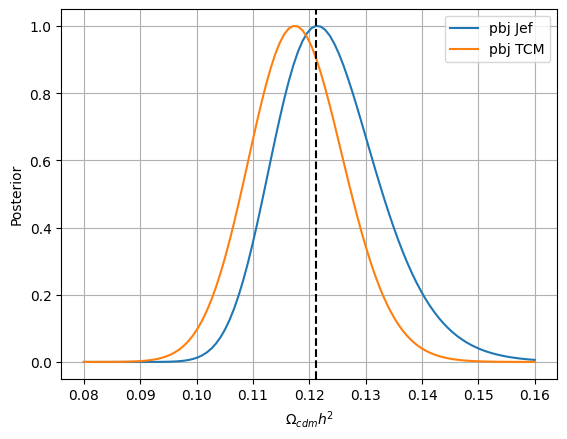

In [18]:
#plt.plot(omch2_AM, likelihood_vals_pbj_AM,label = 'pbj')
plt.plot(omch2_AM, likelihood_vals_pbj_AM_Jef,label = 'pbj Jef')
plt.plot(omch2_AM, likelihood_vals_pbj_AM_TCM,label = 'pbj TCM')
plt.axvline(0.27 * 0.67**2, color='k', ls='--')


#plt.xticks([])
plt.grid(True)
plt.xlabel(r'$\Omega_{cdm} h^2$')
plt.ylabel('Posterior')
plt.legend()

In [22]:
from tqdm import tqdm
loglike_vals_pbj = []

pars_var_pbj = deepcopy(parameters_pbj)
w0_AM = np.linspace(-3., -0.5, 100)

for val in tqdm(w0_AM, desc="Computing likelihood"):
    # Update Omega_cdm0 parameter, making sure it's in the right form
    pars_var_pbj['w0'] = val 
    loglike_vals_pbj.append(like_AM_pbj.loglike_AM(pars_var_pbj, use_Jeffreys=False, do_reparam=True))


loglike_vals_pbj = np.array(loglike_vals_pbj)

# Convert log-likelihood to likelihood (unnormalized)
likelihood_vals_pbj_AM_TCM= np.exp(loglike_vals_pbj - np.max(loglike_vals_pbj))  # subtract max for numerical stability

Computing likelihood: 100%|██████████| 100/100 [00:42<00:00,  2.34it/s]


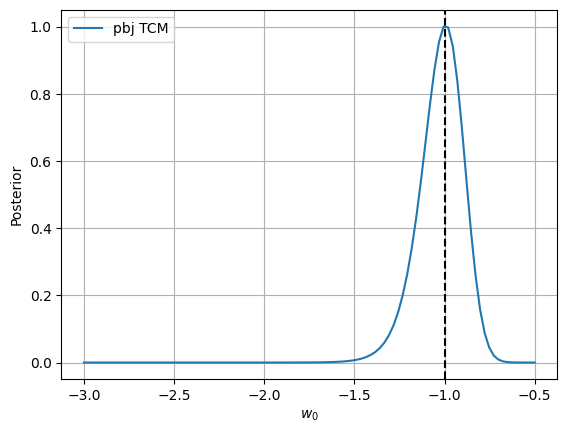

In [23]:

plt.plot(w0_AM, likelihood_vals_pbj_AM_TCM,label = 'pbj TCM')
plt.axvline(-1, color='k', ls='--')


#plt.xticks([])
plt.grid(True)
plt.xlabel('$w_0$')
plt.ylabel('Posterior')
plt.legend()

In [20]:
As_AM = np.linspace(1.8e-9, 2.5e-9, 100)
loglike_vals_comet = []
loglike_vals_pbj = []

pars_var_pbj = deepcopy(parameters_pbj)
pars_var_comet = deepcopy(parameters)
for val in tqdm(As_AM, desc="Computing likelihood"):
    # Update Omega_cdm0 parameter, making sure it's in the right form
    pars_var_comet['As'] = val
    pars_var_pbj['As'] = val 
    loglike_vals_comet.append(like_AM_comet.loglike_AM(pars_var_comet))
    loglike_vals_pbj.append(like_AM_pbj.loglike_AM(pars_var_pbj))

loglike_vals_comet = np.array(loglike_vals_comet)
loglike_vals_pbj = np.array(loglike_vals_pbj)

# Convert log-likelihood to likelihood (unnormalized)
likelihood_vals_comet_AM = np.exp(loglike_vals_comet - np.max(loglike_vals_comet))  # subtract max for numerical stability
likelihood_vals_pbj_AM = np.exp(loglike_vals_pbj - np.max(loglike_vals_pbj))  # subtract max for numerical stability

Computing likelihood: 100%|██████████| 100/100 [00:26<00:00,  3.77it/s]


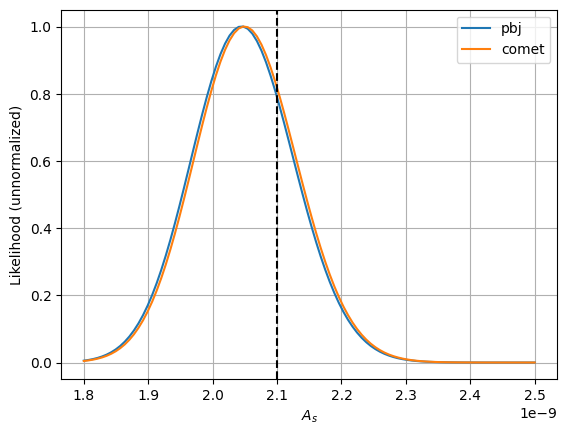

In [21]:
plt.plot(As_AM, likelihood_vals_pbj_AM,label = 'pbj')
plt.plot(As_AM, likelihood_vals_comet_AM, label = 'comet')

plt.axvline(2.1e-9, color='k', ls='--')

#plt.xticks([])
plt.grid(True)
plt.xlabel(r'$A_s$')
plt.ylabel('Likelihood (unnormalized)')
plt.legend()